In [66]:
import sys
from pathlib import Path

# Go to project root (REALTIMEFRAUDDETECTION)
project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow

In [68]:
from src.models.IsolationForest import IsolationForestModel
from src.models.SelfOrganizingMap import SOMModel
from src.models.AutoEncoder import AutoEncoderModel
from src.training.train import trainmodel

In [69]:
import warnings
warnings.filterwarnings("ignore")

In [70]:
df=pd.read_csv("../data/dataset.csv")
df.shape

(1048575, 23)

In [71]:
df.columns

Index(['TransactionID', 'Time', 'Account Number', 'Card Number',
       'Transaction Type', 'Channel', 'Transaction Amount', 'Merchand Group',
       'Country', 'Country 2', 'City 2', 'Card Type', 'Age', 'Gender', 'Bank',
       'City', 'Merchand Code', 'Client Type', 'Account Type',
       'Account Creation Date', 'Client ID', 'Accounts per Client',
       'Has Multiple Accounts'],
      dtype='object')

In [72]:
df['Time']=pd.to_datetime(df['Time'])
df['Account Creation Date']=pd.to_datetime(df['Account Creation Date'])
df['Age']=df['Age'].astype(int)

df['Hour']=df['Time'].dt.hour
df['Date']=df['Time'].dt.date

In [73]:
df.sort_values(['Account Number','Time'],inplace=True)
df['rank']=df.groupby("Account Number")['Time'].rank(method='first',pct=True)

# Feature Engineering

In [74]:
from src.features.TimeFeatures import ComputeTimeFeatures
from src.features.CatEntropy import ComputeCatEntropy
from src.features.CatFreq import ComputeCatFreq
from src.features.CatFeatures import CatEncoding
from src.preprocessing.TrainTestSplit import split
from sklearn.preprocessing import StandardScaler,MinMaxScaler

In [75]:
df=ComputeTimeFeatures(df)
df=ComputeCatEntropy(df)
df=ComputeCatFreq(df)
df=CatEncoding(df)

In [76]:
df.columns

Index(['TransactionID', 'Time', 'Account Number', 'Card Number',
       'Transaction Type', 'Channel', 'Transaction Amount', 'Merchand Group',
       'Country', 'Country 2', 'City 2', 'Card Type', 'Age', 'Gender', 'Bank',
       'City', 'Merchand Code', 'Client Type', 'Account Type',
       'Account Creation Date', 'Client ID', 'Accounts per Client',
       'Has Multiple Accounts', 'Hour', 'Date', 'rank', 'LogAmount',
       'MovingAvg', 'MovingStd', 'TimeDiff', 'LogTimeDiff',
       'FirstTransactionDiff', 'TransactionTypeEntropy', 'ChannelEntropy',
       'CardTypeEntropy', 'MerchandEntropy', 'CountryEntropy', 'CityEntropy',
       'TransactionTypeFreq', 'ChannelFreq', 'CardTypeFreq', 'MerchandFreq',
       'CountryFreq', 'CityFreq', 'Account Type_Business',
       'Account Type_Checking', 'Account Type_Corporate',
       'Account Type_Savings', 'Client Type_PMO', 'Client Type_PPH',
       'Client Type_PRO'],
      dtype='object')

In [ ]:
df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

df=df[['Age','rank',
       'LogAmount', 'MovingAvg','MovingStd', 'LogTimeDiff','FirstTransactionDiff','Hour',
       'TransactionTypeEntropy', 'ChannelEntropy','CardTypeEntropy', 'MerchandEntropy', 'CountryEntropy', 'CityEntropy',
       'TransactionTypeFreq','ChannelFreq','CardTypeFreq', 'MerchandFreq', 'CountryFreq','CityFreq']]

In [78]:
scaler=StandardScaler()
dfscaled=scaler.fit_transform(df)
dfscaled=pd.DataFrame(dfscaled,columns=df.columns,index=df.index)

In [79]:
normalizer=MinMaxScaler()
dfnorm=normalizer.fit_transform(df)
dfnorm=pd.DataFrame(dfnorm,columns=df.columns,index=df.index)

In [80]:
traindf,testdf=split(dfnorm)

In [81]:
traindf.shape

(838048, 20)

# Models

In [82]:
iso=IsolationForestModel(nestimators=200,maxsamples=265,contamination=0.05)
trainmodel(iso,traindf)

{'score_mean': -0.17250142737690283,
 'score_std': 0.06617042022028807,
 'score_skew': 2.0080936568285765,
 'score_p95': -1.173921490445456e-16,
 'score_p99': 0.047070057649714676,
 'tailsep': 0.13707311524608376}

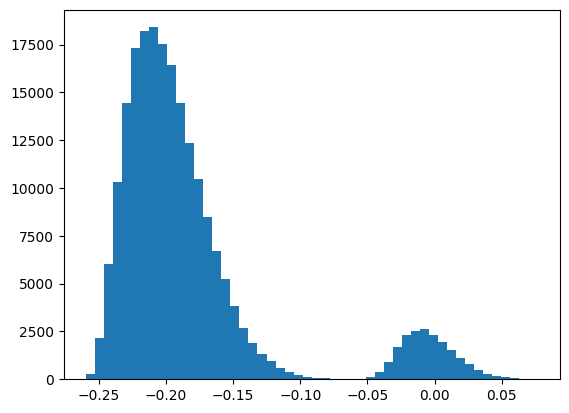

In [83]:
isoscores=iso.score(testdf)
plt.hist(isoscores,bins=50)
plt.show()

In [84]:
ae=AutoEncoderModel(inputdim=traindf.shape[1],lr=0.001,batchsize=1024,epochs=30)
trainmodel(ae,traindf)

Epoch 1/30
737/737 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0698 - val_loss: 0.0230
Epoch 2/30
737/737 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0191 - val_loss: 0.0175
Epoch 3/30
737/737 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0165 - val_loss: 0.0167
Epoch 4/30
737/737 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0161 - val_loss: 0.0163
Epoch 5/30
737/737 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0159 - val_loss: 0.0161
Epoch 6/30
737/737 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0157 - val_loss: 0.0158
Epoch 7/30
737/737 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0156 - val_loss: 0.0157
Epoch 8/30
737/737 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0155 - val_loss: 0.0156
Epoch 9/30
737/737 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0154 - val_loss: 0.0155
Epoch 10/30
737/737 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0154 - val_loss: 0.0155
Epoch 11/30
737/737 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0153 - val_loss: 0.0155
Epoch 12/30
737/737 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step

{'score_mean': 0.015282456912581543,
 'score_std': 0.01324117279369862,
 'score_skew': 3.4192469035774318,
 'score_p95': 0.042204826884144404,
 'score_p99': 0.05422557487201835,
 'tailsep': 0.019765241038380774}

6579/6579 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step


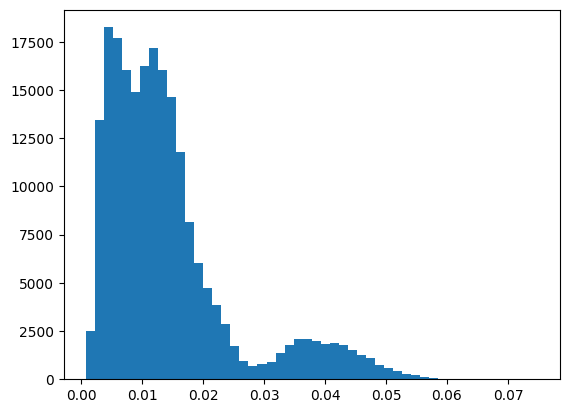

In [85]:
aescores=ae.score(testdf)
plt.hist(aescores,bins=50)
plt.show()

In [86]:
som=SOMModel(inputlen=traindf.shape[1],x=20,y=20,sigma=1,learning_rate=0.5,iterations=10000)
trainmodel(som,traindf)

{'score_mean': 0.3399351320968377,
 'score_std': 0.12500656212623684,
 'score_skew': 1.1838658728116913,
 'score_p95': 0.5572153821729375,
 'score_p99': 0.7480832174734922,
 'tailsep': 0.24999305971966823}

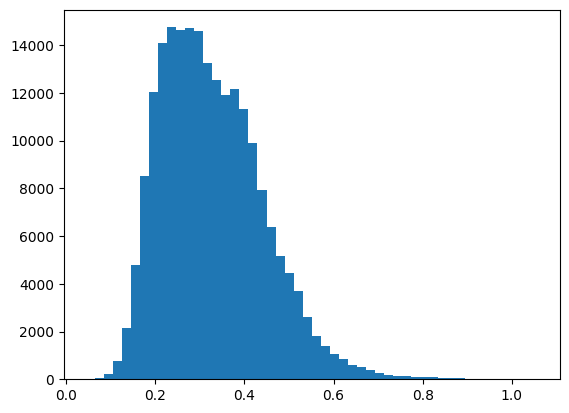

In [87]:
somscores=som.score(testdf)
plt.hist(somscores,bins=50)
plt.show()

# Results Exploration

In [88]:
from sklearn.preprocessing import minmax_scale

In [89]:
results=testdf.copy()

In [90]:
results['isoscores']=iso.score(testdf)
results['somscores']=som.score(testdf)
results['aescores']=ae.score(testdf)

6579/6579 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step


In [91]:
results['isoscores']=minmax_scale(results['isoscores'])
results['somscores']=minmax_scale(results['somscores'])
results['aescores']=minmax_scale(results['aescores'])

In [92]:
corr=results[['isoscores','somscores','aescores']].corr(method='spearman')
corr

,isoscores,somscores,aescores
isoscores,1.000000,0.559007,0.596143
somscores,0.559007,1.000000,0.361629
aescores,0.596143,0.361629,1.000000


In [93]:
topscores=int(results.shape[0]*0.01)
isoresult=results.sort_values(by='isoscores',ascending=False).iloc[:topscores]
somresult=results.sort_values(by='somscores',ascending=False).iloc[:topscores]
aeresult=results.sort_values(by='aescores',ascending=False).iloc[:topscores]

In [94]:
overlap=len(set(isoresult.index)&set(aeresult.index)&set(somresult.index))/topscores
overlap*100

2.470308788598575

In [95]:
from scipy.stats import rankdata

def rank_normalize_df(df_scores):
    return df_scores.apply(lambda col: rankdata(col) / len(col))

In [96]:
dfranked=rank_normalize_df(results)

In [97]:
def top_k_idx(series, k=0.01):
    n = len(series)
    k = int(n * k)
    return set(series.nlargest(k).index)

In [98]:
def top_k_overlap(df, col1, col2, k=0.01):
    top1 = top_k_idx(df[col1], k)
    top2 = top_k_idx(df[col2], k)
    return len(top1 & top2) / len(top1)

In [99]:
def overlap_matrix(df, k=0.05):
    cols = ['isoscores','somscores','aescores']
    result = {}

    for c1 in cols:
        result[c1] = {}
        for c2 in cols:
            result[c1][c2] = top_k_overlap(df, c1, c2, k)

    return result

In [100]:
overlap=overlap_matrix(dfranked)
print(overlap)

{'isoscores': {'isoscores': 1.0, 'somscores': 0.5060801824054721, 'aescores': 0.015390461713851415}, 'somscores': {'isoscores': 0.5060801824054721, 'somscores': 1.0, 'aescores': 0.12578377351320538}, 'aescores': {'isoscores': 0.015390461713851415, 'somscores': 0.12578377351320538, 'aescores': 1.0}}


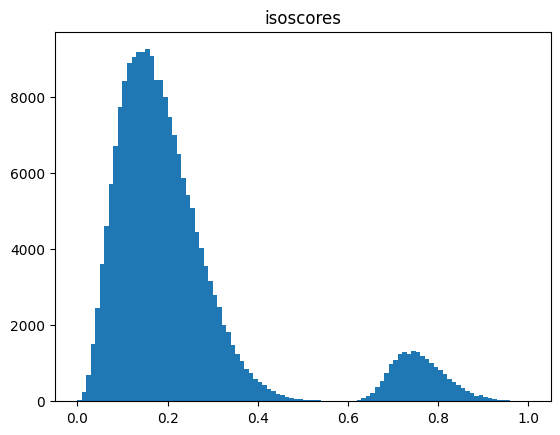

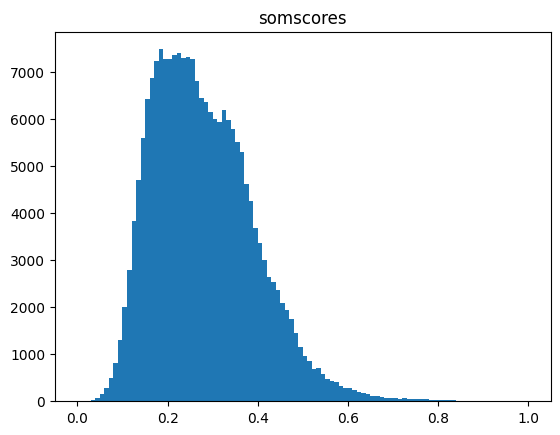

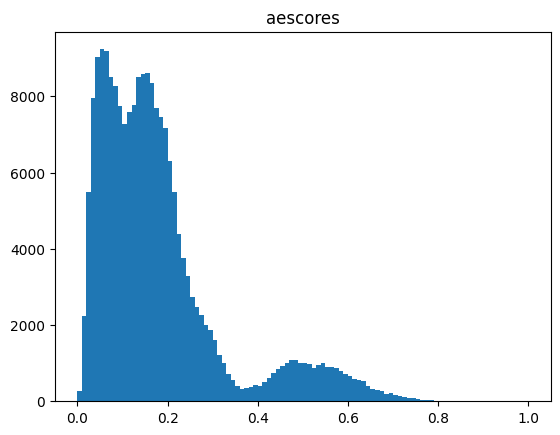

In [101]:
import matplotlib.pyplot as plt

for col in ['isoscores','somscores','aescores']:
    plt.hist(results[col], bins=100)
    plt.title(col)
    plt.show()